In [1]:
import os
import random
import shutil
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

In [4]:
train_dir = "/mnt/d/deep learning/projects/testing/train"
test_dir = "/mnt/d/deep learning/projects/testing/test"

classes_to_use = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']  # disgust removed
classes_to_use

['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Number of Train images in angry:  3995
Number of Train images in fear:  4097
Number of Train images in happy:  7215
Number of Train images in neutral:  4965
Number of Train images in sad:  4830
Number of Train images in surprise:  3171


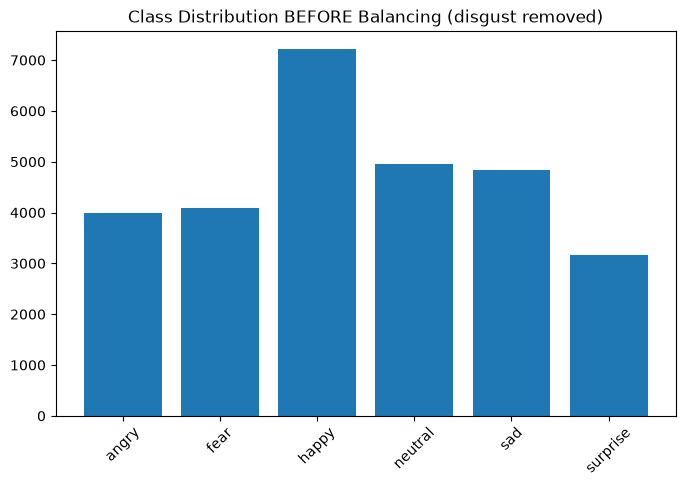

In [5]:
class_counts = {}
for classes in classes_to_use:
    class_path = os.path.join(train_dir, classes)
    img_name = os.listdir(class_path)
    class_counts[classes] = len(img_name)
    print(f"Number of Train images in {classes}: ", len(img_name))

plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution BEFORE Balancing (disgust removed)")
plt.xticks(rotation=45)
plt.show()

In [6]:
# happy has the most images (7215), disgust has the fewest (436)
# we balance every class toward one target count so no class dominates
# training, and no class is duplicated an extreme number of times

target_count = 5000   # tune this if you want (try 4000 if disgust overfits)

print("Target images per class:", target_count)

Target images per class: 5000


In [7]:
def augment_image(img):
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    angle = random.uniform(-15, 15)
    img = img.rotate(angle, fillcolor=0)

    enhancer = ImageEnhance.Brightness(img)
    factor = random.uniform(0.8, 1.2)
    img = enhancer.enhance(factor)

    if random.random() < 0.5:
        w, h = img.size
        crop_percent = random.uniform(0.85, 0.95)
        new_w, new_h = int(w * crop_percent), int(h * crop_percent)
        left = random.randint(0, w - new_w)
        top = random.randint(0, h - new_h)
        img = img.crop((left, top, left + new_w, top + new_h))
        img = img.resize((w, h))

    return img

In [8]:
train_balanced_dir = "../data/train_balanced_no_disgust"

if not os.path.exists(train_balanced_dir):
    os.makedirs(train_balanced_dir)

for classes in classes_to_use:
    class_path = os.path.join(train_dir, classes)
    balanced_class_path = os.path.join(train_balanced_dir, classes)

    if not os.path.exists(balanced_class_path):
        os.makedirs(balanced_class_path)

    img_name = os.listdir(class_path)
    current_count = len(img_name)

    if current_count > target_count:
        selected_imgs = random.sample(img_name, target_count)
        for img in selected_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(balanced_class_path, img)
            shutil.copy(src, dst)
    else:
        for img in img_name:
            src = os.path.join(class_path, img)
            dst = os.path.join(balanced_class_path, img)
            shutil.copy(src, dst)

        needed = target_count - current_count
        generated = 0
        while generated < needed:
            random_img_name = random.choice(img_name)
            img_path = os.path.join(class_path, random_img_name)

            img = Image.open(img_path).convert("L")
            aug_img = augment_image(img)

            new_name = f"aug_{generated}_{random_img_name}"
            save_path = os.path.join(balanced_class_path, new_name)
            aug_img.save(save_path)

            generated += 1

    print(f"{classes}: done, target = {target_count}")

print("Balancing complete (no disgust)")

angry: done, target = 5000
fear: done, target = 5000
happy: done, target = 5000
neutral: done, target = 5000
sad: done, target = 5000
surprise: done, target = 5000
Balancing complete (no disgust)


Number of Balanced Train images in angry:  5000
Number of Balanced Train images in fear:  5000
Number of Balanced Train images in happy:  5000
Number of Balanced Train images in neutral:  5000
Number of Balanced Train images in sad:  5000
Number of Balanced Train images in surprise:  5000


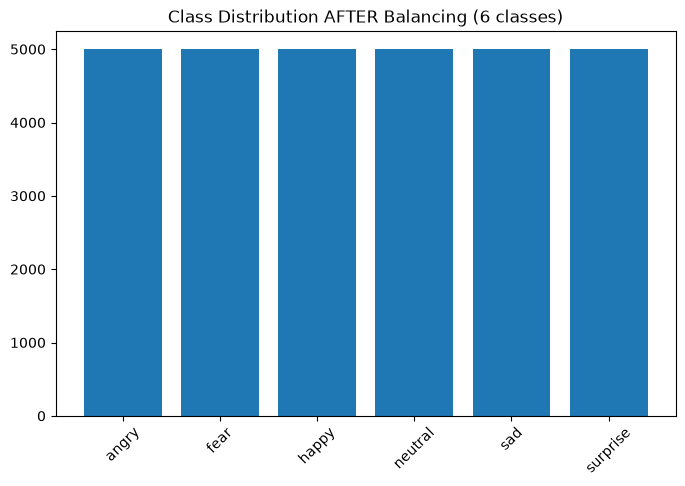

In [9]:
balanced_class_counts = {}
for classes in os.listdir(train_balanced_dir):
    class_path = os.path.join(train_balanced_dir, classes)
    img_name = os.listdir(class_path)
    balanced_class_counts[classes] = len(img_name)
    print(f"Number of Balanced Train images in {classes}: ", len(img_name))

plt.figure(figsize=(8,5))
plt.bar(balanced_class_counts.keys(), balanced_class_counts.values())
plt.title("Class Distribution AFTER Balancing (6 classes)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# test set must stay untouched in size, dropping the disgust folder
# so keras's image_dataset_from_directory only sees 6 classes

test_filtered_dir = "../data/test_no_disgust"

if not os.path.exists(test_filtered_dir):
    os.makedirs(test_filtered_dir)

for classes in classes_to_use:
    src_class_path = os.path.join(test_dir, classes)
    dst_class_path = os.path.join(test_filtered_dir, classes)

    if not os.path.exists(dst_class_path):
        os.makedirs(dst_class_path)

    for img in os.listdir(src_class_path):
        shutil.copy(os.path.join(src_class_path, img), os.path.join(dst_class_path, img))

    print(f"{classes}: copied {len(os.listdir(dst_class_path))} test images")

angry: copied 958 test images
fear: copied 1024 test images
happy: copied 1774 test images
neutral: copied 1233 test images
sad: copied 1247 test images
surprise: copied 271 test images
